c:\Users\ACER\OneDrive\Documents\26HK2 - Thị Giác Máy Tính\2374802010299_LuuVoPhuongMai_Lab03
['hinh1.jpg', 'hinh2.jpg']
img type: <class 'numpy.ndarray'>
img dtype: uint8
img shape (H, W, C): (300, 828, 3)
img2 type: <class 'numpy.ndarray'>
img2 dtype: uint8
img2 shape (H, W, C): (300, 828, 3)


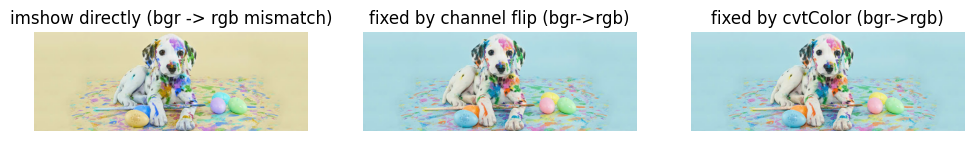

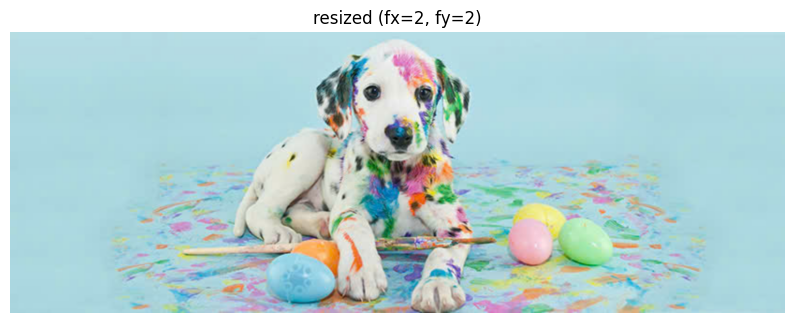

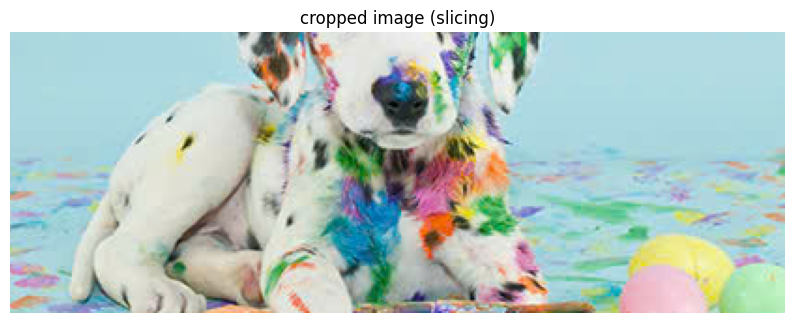

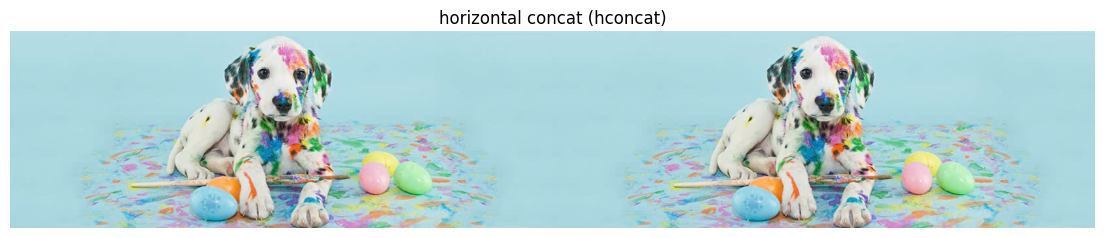

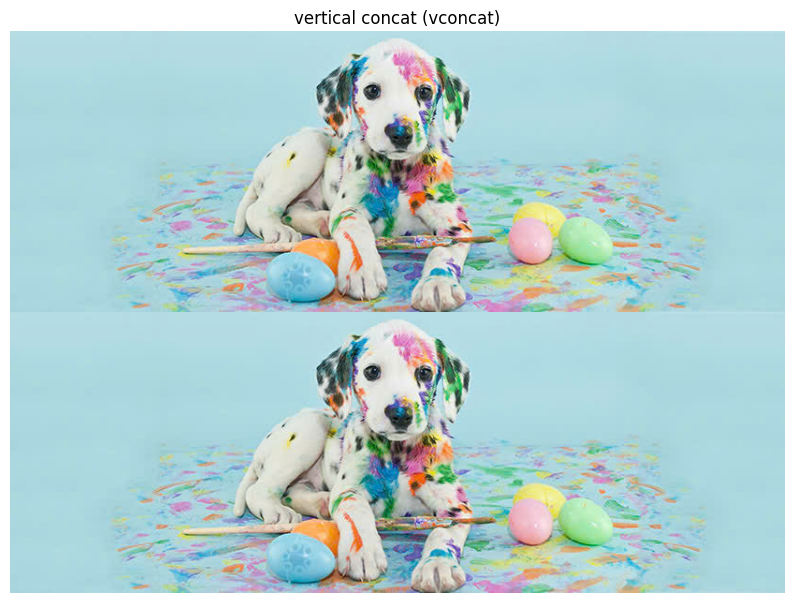

In [11]:
import cv2
import matplotlib.pyplot as LuuMai

import os
print(os.getcwd())
print([f for f in os.listdir() if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])


# 2. kiểm tra xem opencv đọc ảnh như thế nào? hiển thị chiều của ảnh?
img = cv2.imread("hinh1.jpg")
img2 = cv2.imread("hinh2.jpg")

print("img type:", type(img))
print("img dtype:", img.dtype)
print("img shape (H, W, C):", img.shape)

print("img2 type:", type(img2))
print("img2 dtype:", img2.dtype)
print("img2 shape (H, W, C):", img2.shape)

# 3. show hình ảnh ra cho trực quan, sử dụng plt.imshow. nhận xét + hiển thị đúng (đảo chiều matrix / convert màu)
LuuMai.figure(figsize=(12, 6))

LuuMai.subplot(1, 3, 1)
LuuMai.imshow(img)  
LuuMai.title("imshow directly (bgr -> rgb mismatch)")
LuuMai.axis("off")

LuuMai.subplot(1, 3, 2)
img_flip_channel = img[:, :, ::-1]  
LuuMai.imshow(img_flip_channel)
LuuMai.title("fixed by channel flip (bgr->rgb)")
LuuMai.axis("off")

LuuMai.subplot(1, 3, 3)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
LuuMai.imshow(img_rgb)
LuuMai.title("fixed by cvtColor (bgr->rgb)")
LuuMai.axis("off")

LuuMai.show()

# 4. nếu muốn phóng to ảnh thì chúng ta làm gì? (resize)
img_big = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

LuuMai.figure(figsize=(10, 6))
LuuMai.imshow(cv2.cvtColor(img_big, cv2.COLOR_BGR2RGB))
LuuMai.title("resized (fx=2, fy=2)")
LuuMai.axis("off")
LuuMai.show()

# 5. nếu muốn crop ảnh thì chúng ta làm gì? (slicing)
h, w = img.shape[:2]
y1, y2 = h // 4, 3 * h // 4
x1, x2 = w // 4, 3 * w // 4
crop_img = img[y1:y2, x1:x2]

LuuMai.figure(figsize=(10, 6))
LuuMai.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
LuuMai.title("cropped image (slicing)")
LuuMai.axis("off")
LuuMai.show()

# 6. ghép dọc và ghép ngang 2 bức ảnh

if len(img.shape) == 2:
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if len(img2.shape) == 2:
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

h1, w1 = img.shape[:2]
img2_rs = cv2.resize(img2, (w1, h1), interpolation=cv2.INTER_AREA)

img_h = cv2.hconcat([img, img2_rs])  # ghép ngang
img_v = cv2.vconcat([img, img2_rs])  # ghép dọc

LuuMai.figure(figsize=(14, 6))
LuuMai.imshow(cv2.cvtColor(img_h, cv2.COLOR_BGR2RGB))
LuuMai.title("horizontal concat (hconcat)")
LuuMai.axis("off")
LuuMai.show()

LuuMai.figure(figsize=(10, 10))
LuuMai.imshow(cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB))
LuuMai.title("vertical concat (vconcat)")
LuuMai.axis("off")
LuuMai.show()
